## Import

In [3]:
from sklearn.ensemble import RandomForestRegressor

import joblib
import numpy as np

In [4]:
from physics.Iso_data_handler import Iso_data_handler
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

In [10]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/final_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/final_models/"
path_to_models = 'model/final_models/'
tag = "mass_smaller_14"
output_parameters = ["mass", "radius"]
categories_name = ["phase"]

## Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)
print(categories_train.shape, categories_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.0464342686349397
Mean value in train data for the star_mass parameter: 3.3973846370701644

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.048860774010381
Mean value in test data for the star_mass parameter: 3.399812923045874

Range in test data for the log_R parameter : -0.9974234436680278 - 3.0827540579576227
Median value in test data for the log_R parameter: 0.5398730026691951
Mean value in test data for the log_R parameter: 0.6057854356870224

(389468, 4) (129823, 4)
(38

## Getting the final evaluations


mass_smaller_14 train data :
Training the model...
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999981896729906 - 13.99946885003588
  RVE :  0.9999479659026804
  RMSE :  0.023842817554602547
  MAE :  0.006600682969985317
  MedAE :  0.0018220043477459313
  CORR :  0.9999740981739789
  MAX_ER :  1.5966549603659441
  Percentiles : 
    75th percentile :  0.005563209577905903
    90th percentile :  0.01438014497303346
    95th percentile :  0.024895996180043383
    99th percentile :  0.07250033193434297

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 13.92718523912214
  RVE :  0.999968894064049
  RMSE :  0.018261233187159873
  MAE :  0.00891077150198949
  MedAE :  0.004265870624111878
  CORR :  0.9999845110201704
  MAX_ER :  0.4236021894295412
  Percentiles : 
    75th percentile :  0.009601565860669875
    90th percentile :  0.02014669047487204
    95th percentile :

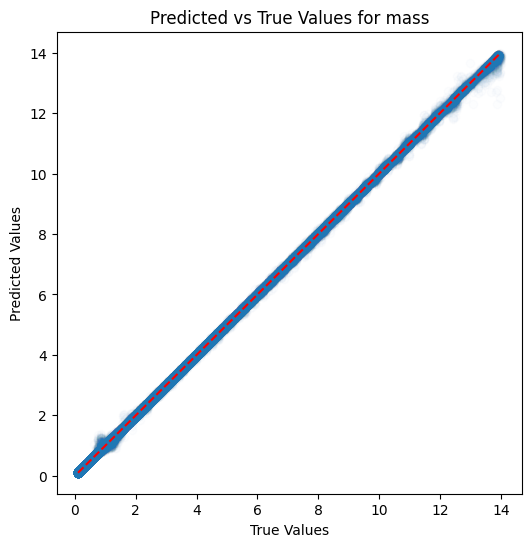

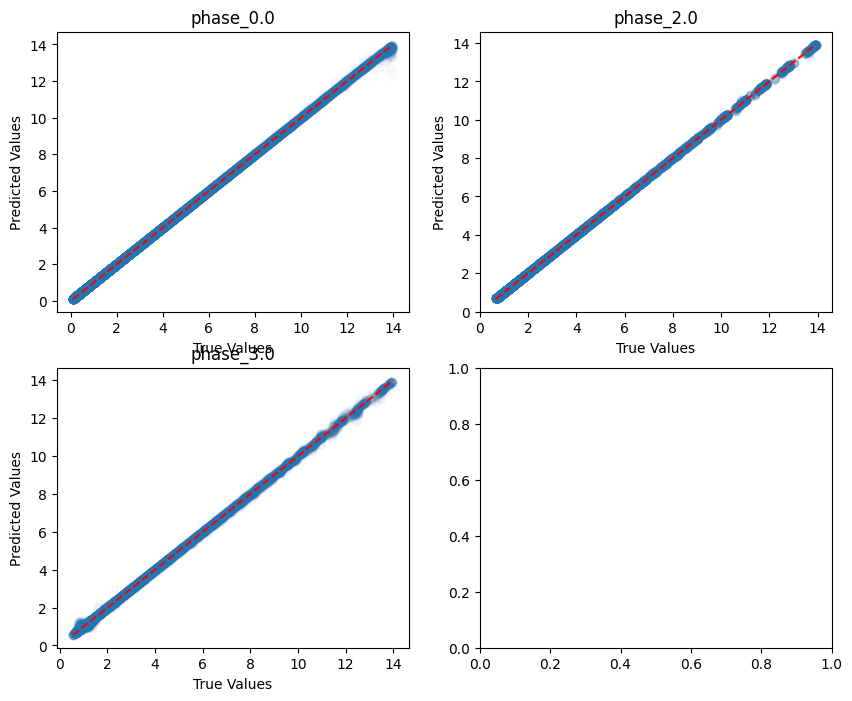

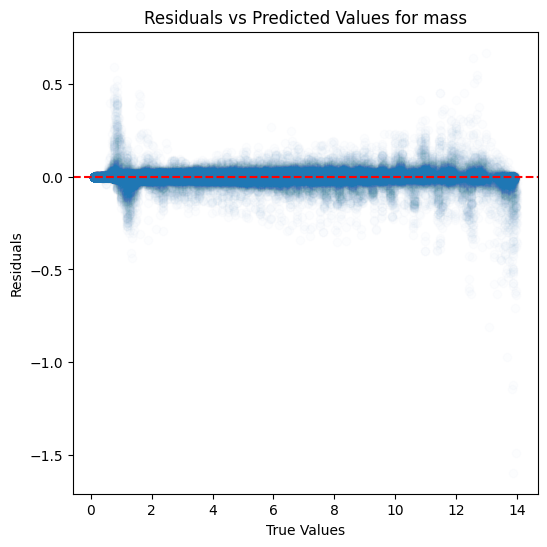

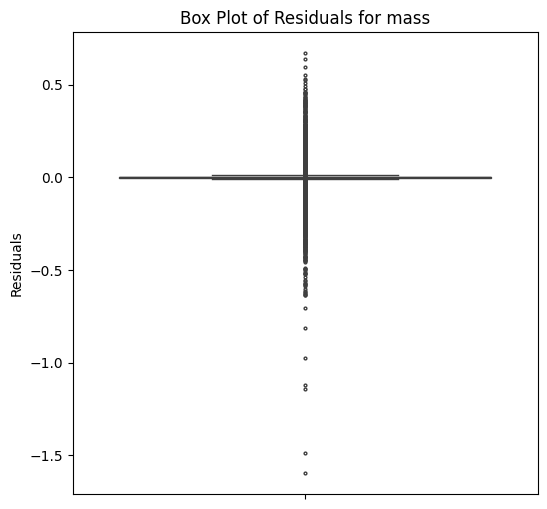

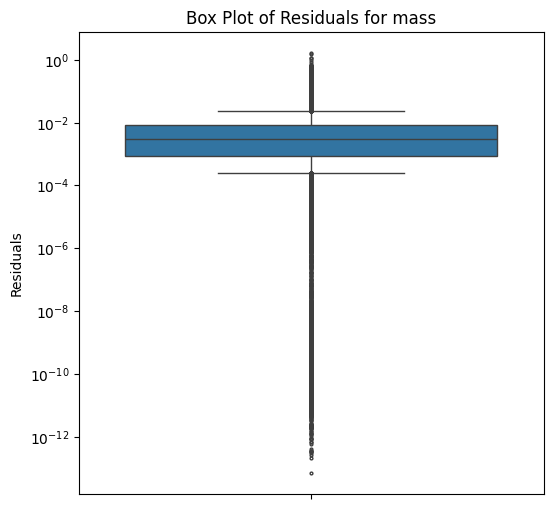

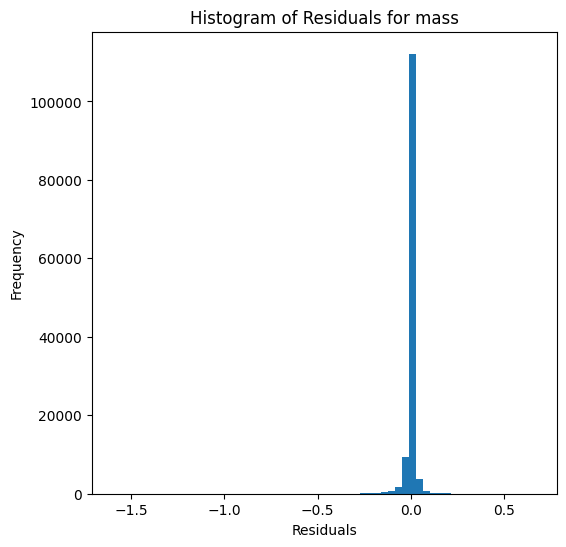

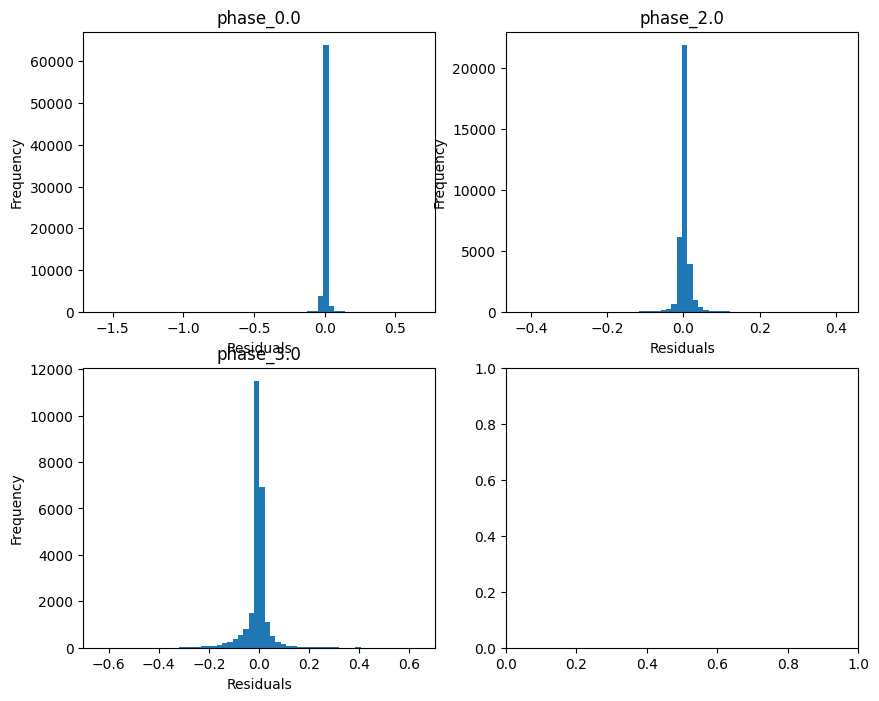

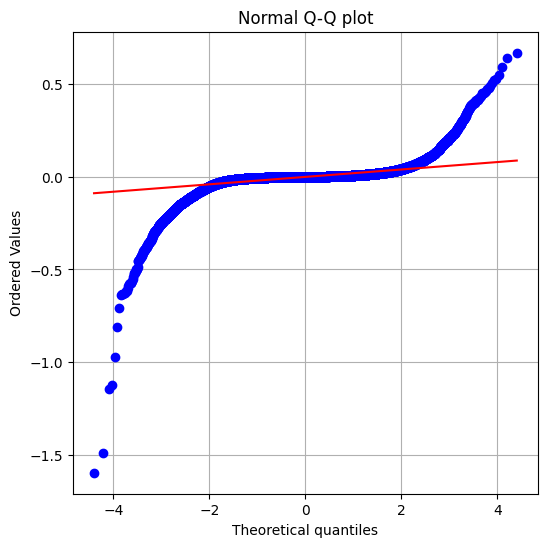

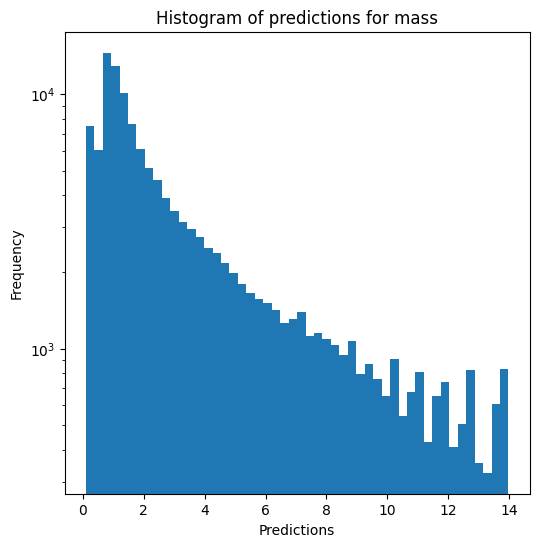

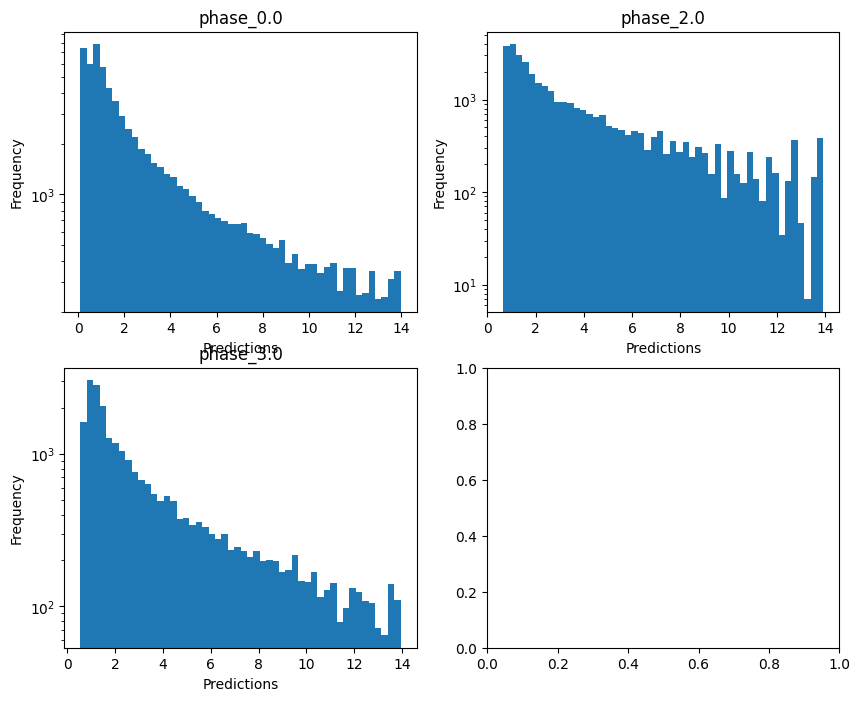


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 3.0827540579576227
  RVE :  0.9999858441501018
  RMSE :  0.0015969272960272927
  MAE :  0.0009078512255848077
  MedAE :  0.0004851231219560881
  CORR :  0.9999929378681205
  MAX_ER :  0.03924002787393466
  Percentiles : 
    75th percentile :  0.001083233244715709
    90th percentile :  0.0022076103079378797
    95th percentile :  0.0032066060614986953
    99th percentile :  0.005929453674662697

radius results for the phase category with a value of 2.0
  value range :  0.0946930588223481 - 2.900376516729969
  RVE :  0.999956376567675
  RMSE :  0.0032531832632433223
  MAE :  0.002270644882819997
  MedAE :  0.0015711480779453946
  CORR :  0.9999805178839399
  MAX_ER :  0.02997372253677666
  Percentiles : 
    75th percentile :  0.0030182898098226607
    90th percentile :  0.005204078171144744
    95th percentile :  0.00702121557235617
    99th percentile :  0.01081680526448791

radius resul

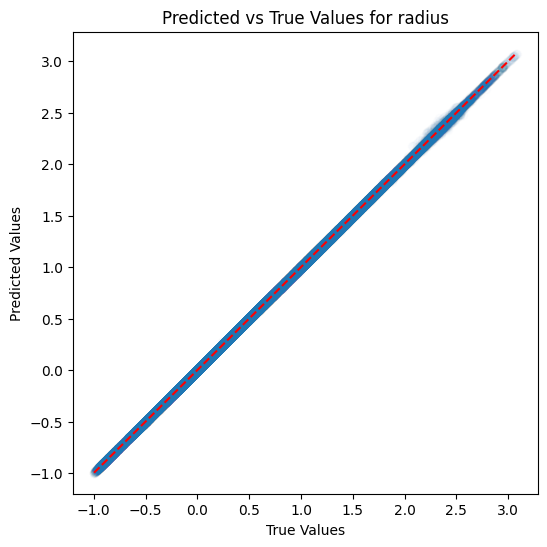

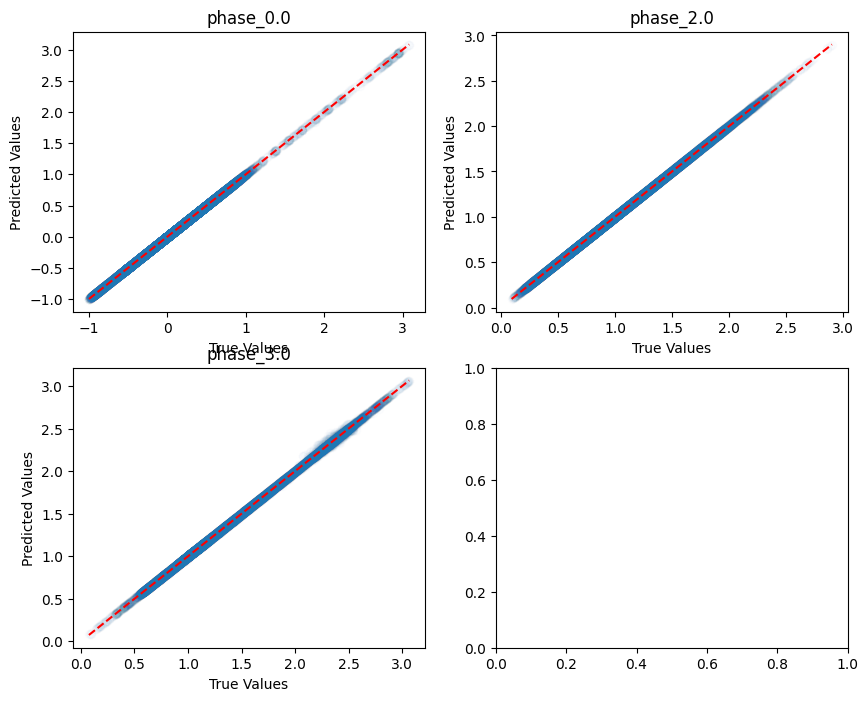

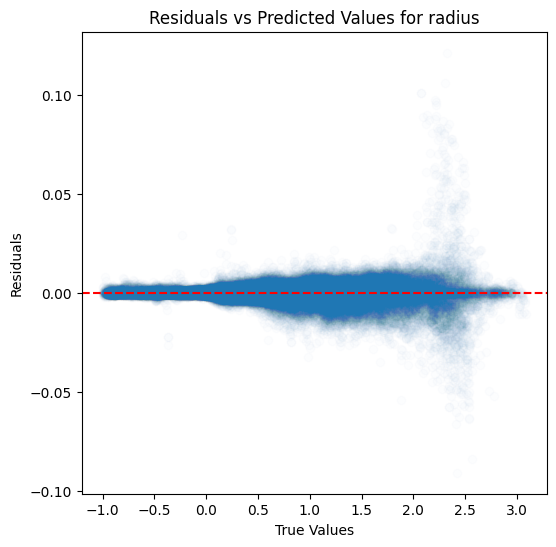

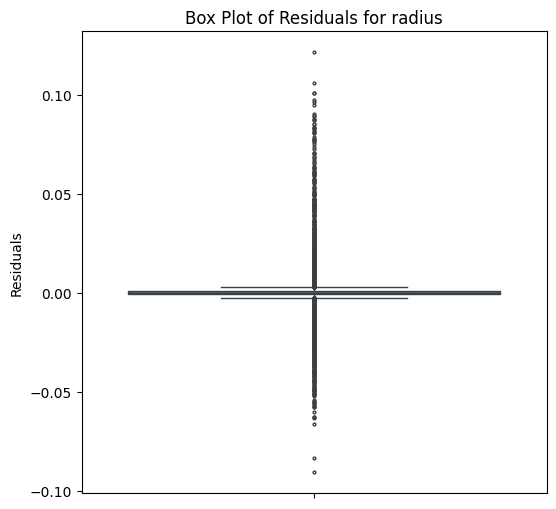

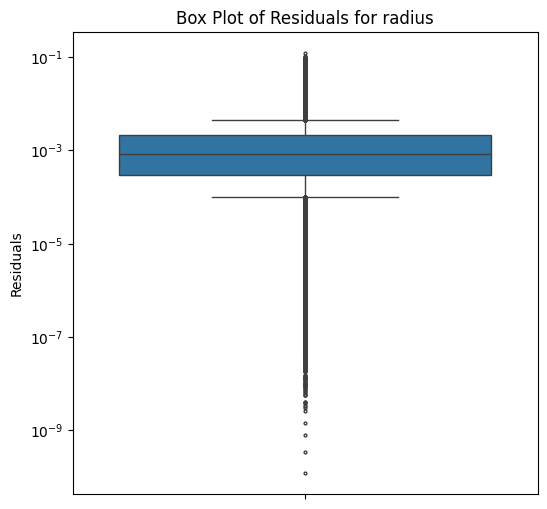

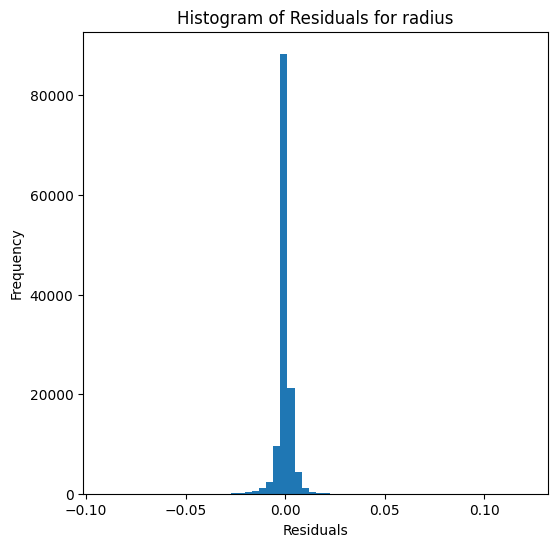

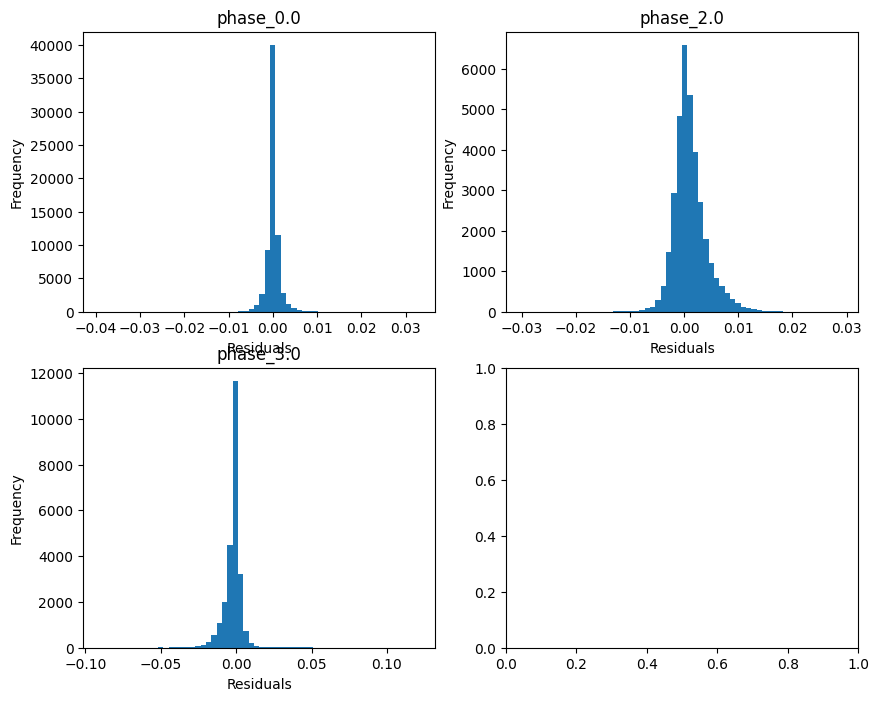

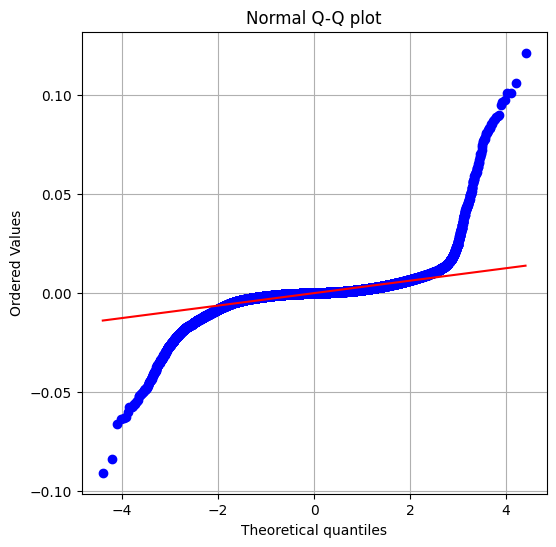

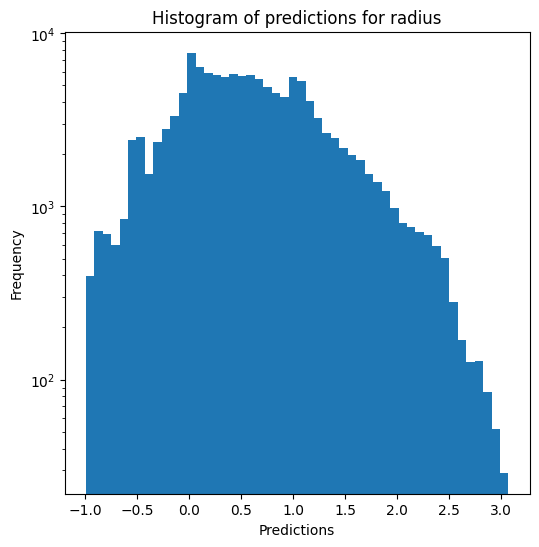

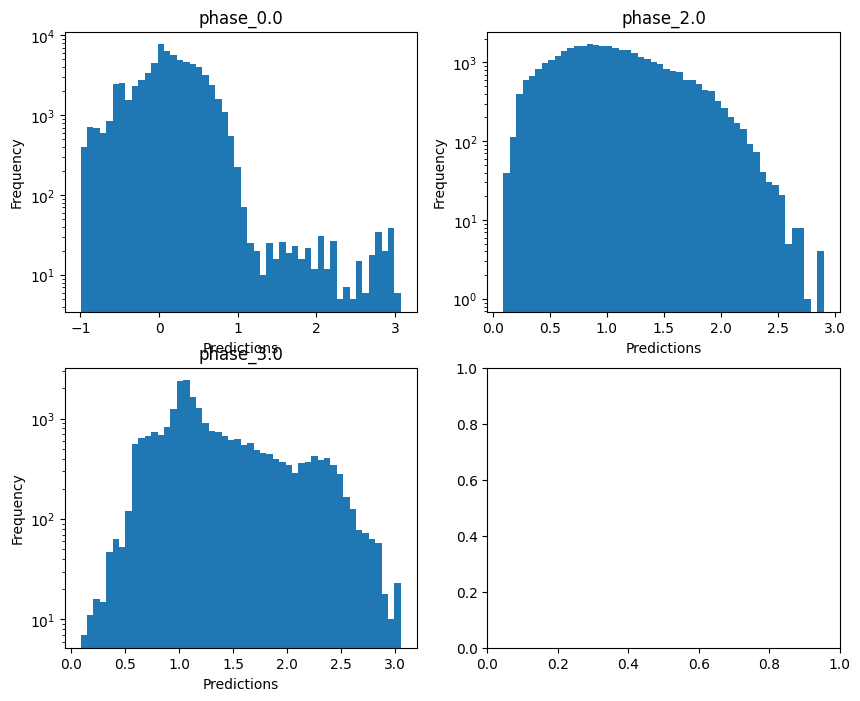

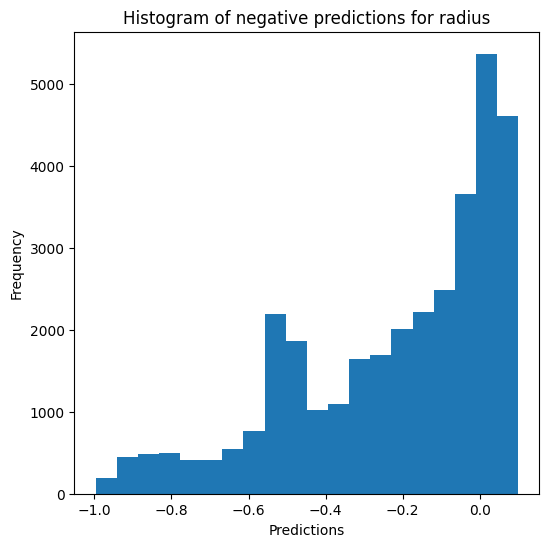

Saving predictions and results...


In [8]:
best_params_RF = {'n_jobs':10, 'n_estimators': 1000, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_RF)

## Training the final model

In [9]:
X = np.append(X_train, X_ivs, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(y.shape)

(519291, 4)
(519291, 2)


In [11]:
best_params_RF = {'n_jobs':10, 'n_estimators': 1000, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X, y)

,n_estimators,1000
,criterion,'squared_error'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "Model_A_partial_RF_compress_0.pkl", compress=0)
# 50 GB
# 3 minutes 50 pour créé le fichier

['../../../../../../model/final_models/Model_A_partial_RF_compress_0.pkl']

In [ ]:
joblib.dump(mdl, pre_path + 'model/final_models/test_Model_A_partial_RF.pkl.z')
# 17.3 GB
# 16 minutes pour créé le fichier

['../../../../../../model/final_models/test_Model_A_partial_RF.pkl.z']

In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "Model_A_partial_RF_compress_3.pkl", compress=3)
# 17.3 GB, 17.1 GB après zip
# 15 minutes 30

['../../../../../../model/final_models/Model_A_partial_RF_compress_3.pkl']